In [1]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.table import Table

project_root = Path("/home/maju/projeto/LS5039")
sys.path.append(str(project_root / "src"))

from periodograma import (
    calcular_lomb_scargle, 
    calcular_lomb_scargle_hz, 
    calcular_funcao_janela, 
    filtrar_periodograma
)

# Parâmetros
ano = "2017"
binagem = "b10s" 
energia = "10_30kev"

arq_entrada = project_root / "data" / "processed" / f"/home/maju/projeto/LS5039/data/processed/sub_2017_b10s_10_30kev.lc"

data = Table.read(str(arq_entrada), hdu=1)

time = np.asarray(data['TIME'], dtype=float)
rate = np.asarray(data['RATE'], dtype=float)
err = np.asarray(data['ERROR'], dtype=float) if 'ERROR' in data.colnames else None

print(f"Ficheiro carregado com sucesso: {arq_entrada}")
print(f"Número de pontos da curva de luz: {len(time)}")

Ficheiro carregado com sucesso: /home/maju/projeto/LS5039/data/processed/sub_2017_b10s_10_30kev.lc
Número de pontos da curva de luz: 177351


In [2]:
# em dias
min_p_busca = 0.05
max_p_busca = 5.0

freq, power, best_freq_bruto, best_p_bruto = calcular_lomb_scargle(
    time, rate, err, min_p=min_p_busca, max_p=max_p_busca
)

freq_win, power_win = calcular_funcao_janela(
    time, min_p=min_p_busca, max_p=max_p_busca
)

corte_min = 14.0
corte_max = 15.0

freq_limpa, power_limpa, best_freq, best_p = filtrar_periodograma(
    freq, power, corte_min, corte_max
)

power_norm_bruto = power / np.max(power)
power_norm_limpo = power_limpa / np.max(power_limpa)

print(f"Melhor Período (Antes do filtro): {best_p_bruto:.4f} dias (f = {best_freq_bruto:.2f} d⁻¹)")
print(f"Melhor Período (Após o filtro)  : {best_p:.4f} dias (f = {best_freq:.2f} d⁻¹)")

Melhor Período (Antes do filtro): 0.0673 dias (f = 14.85 d⁻¹)
Melhor Período (Após o filtro)  : 3.9997 dias (f = 0.25 d⁻¹)


Melhor Frequência Rápida: 0.00064 Hz
Melhor Período Correspondente: 1555.28 segundos


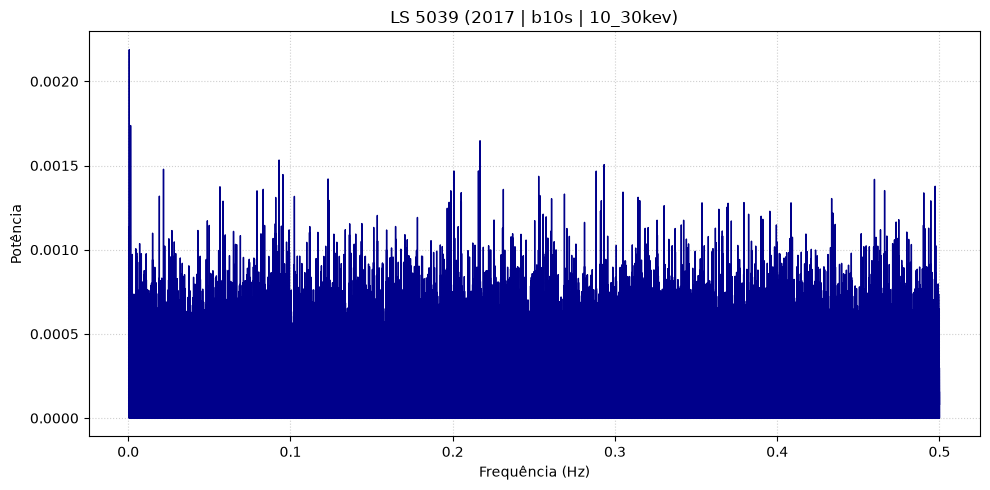

In [3]:

freq_hz, power_hz, best_freq_hz, best_p_seg = calcular_lomb_scargle_hz(
    time, rate, err, min_p_seg=2.0, max_p_seg=1800.0
)

print(f'Melhor Frequência Rápida: {best_freq_hz:.5f} Hz')
print(f'Melhor Período Correspondente: {best_p_seg:.2f} segundos')

plt.figure(figsize=(10, 5))
plt.plot(freq_hz, power_hz, color='darkblue', lw=1.0)

plt.xlabel('Frequência (Hz)')
plt.ylabel('Potência')
plt.title(f'LS 5039 ({ano} | {binagem} | {energia})')
plt.grid(True, ls=':', alpha=0.6)

plt.tight_layout()
plt.show()